Wygenerowano plik mieszkania_warszawa.csv

SHAPE:
(2000, 10)

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_oferty                2000 non-null   int64  
 1   dzielnica                2000 non-null   object 
 2   metraz_m2                2000 non-null   float64
 3   liczba_pokoi             2000 non-null   int64  
 4   pietro                   2000 non-null   int64  
 5   rok_budowy               2000 non-null   int64  
 6   ma_balkon                2000 non-null   bool   
 7   ma_miejsce_parkingowe    2000 non-null   bool   
 8   odleglosc_od_centrum_km  2000 non-null   float64
 9   cena_pln                 2000 non-null   float64
dtypes: bool(2), float64(3), int64(4), object(1)
memory usage: 129.0+ KB
None

DESCRIBE:
          id_oferty    metraz_m2  liczba_pokoi       pietro   rok_budowy  \
count   2000

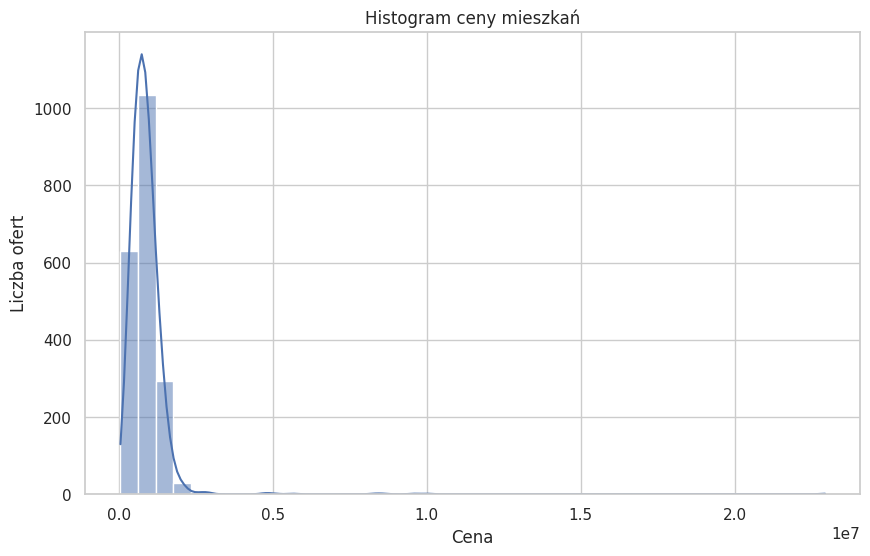

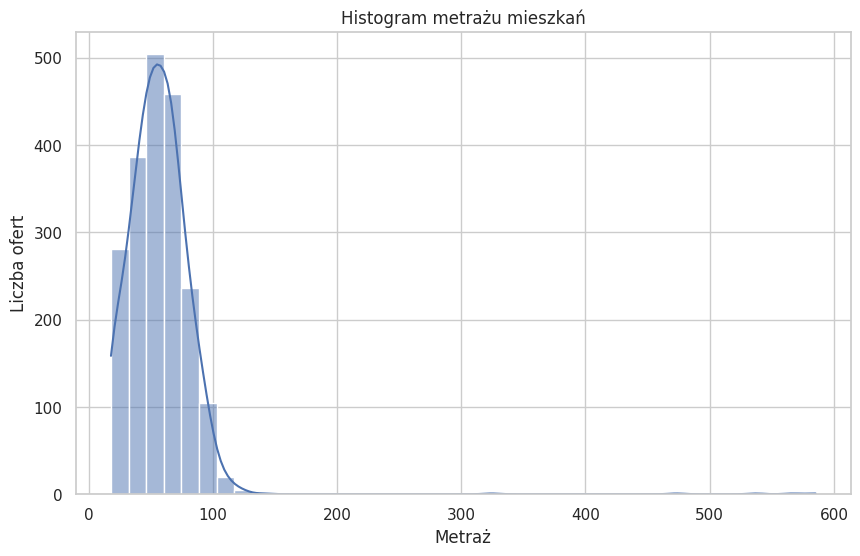


Histogramy pokazują prawostronną skośność.
Występują wartości odstające.



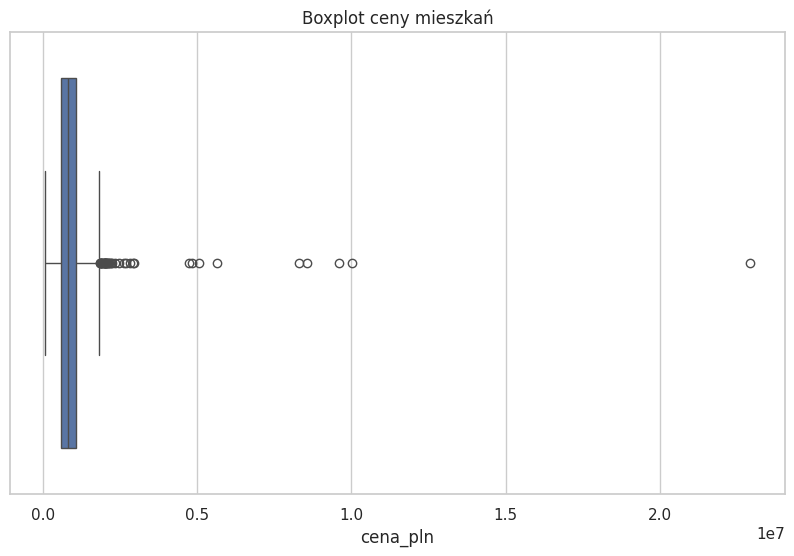


Na boxplocie widać dużą liczbę outlierów cenowych.



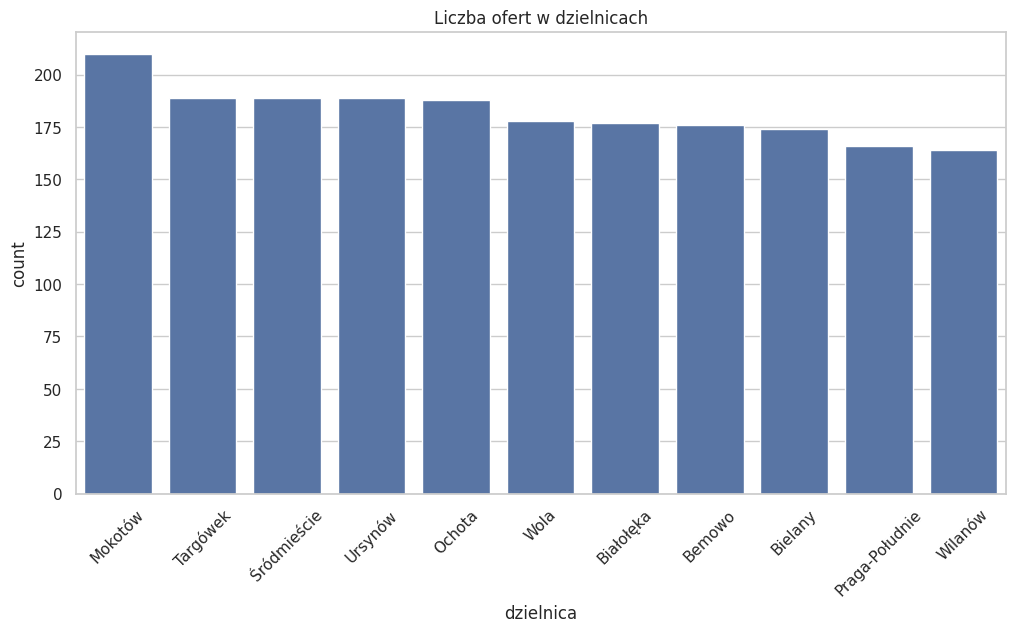

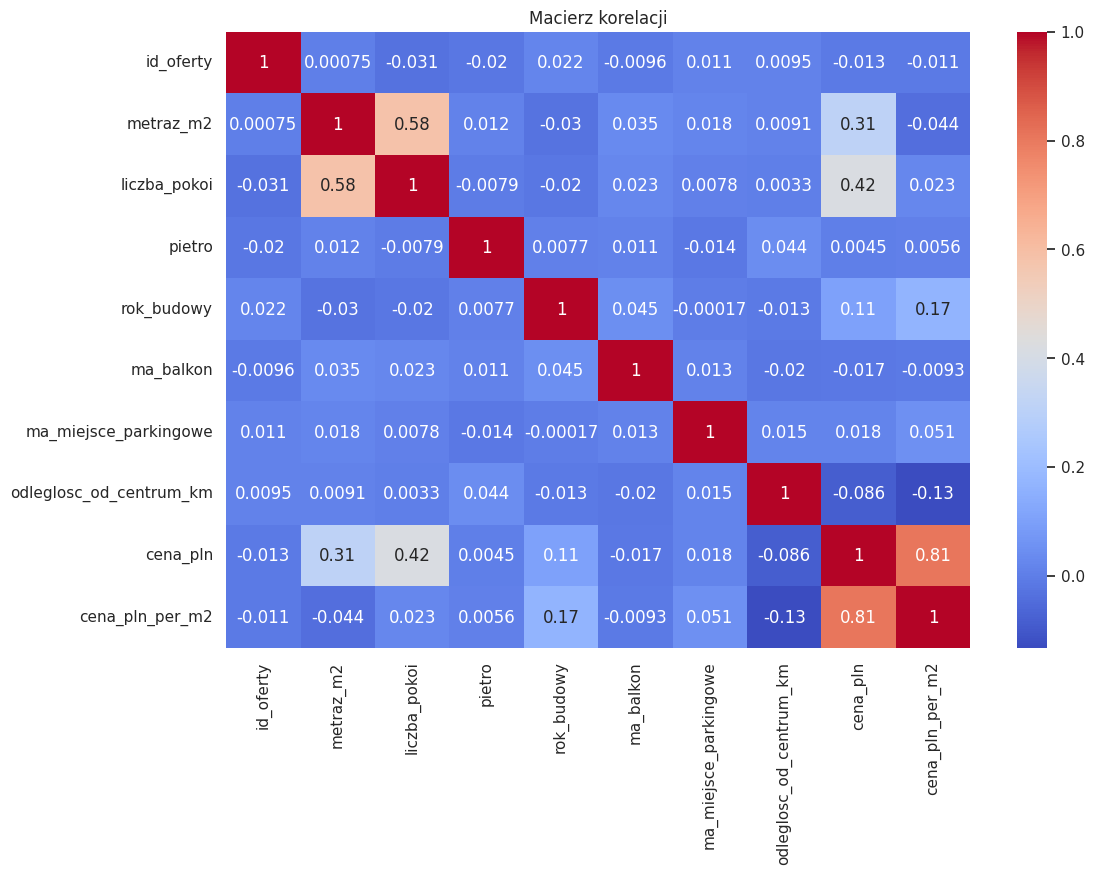


Najsilniej z ceną koreluje metraż mieszkania.



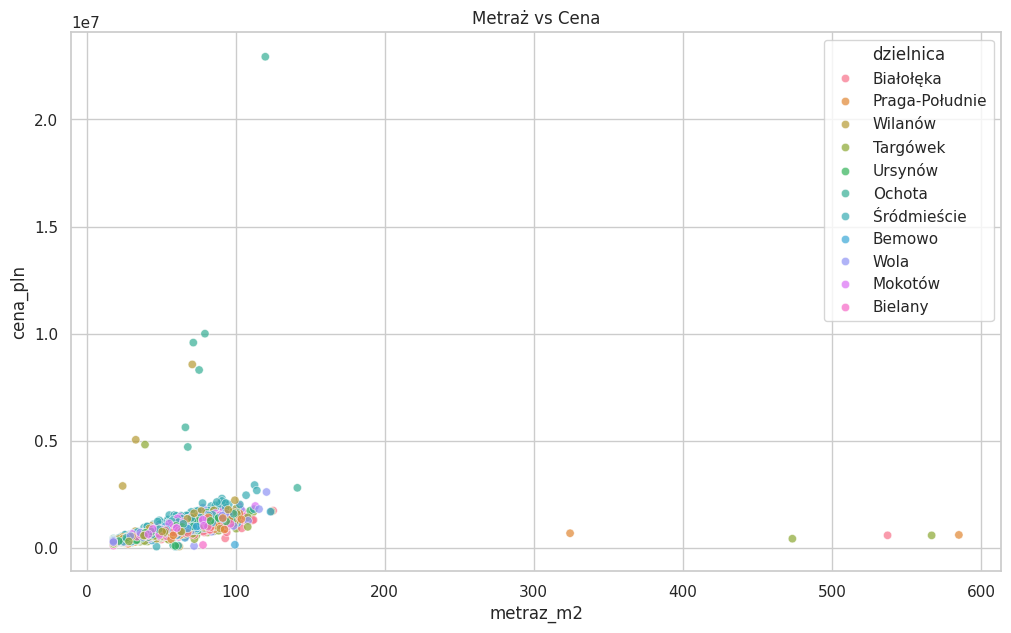

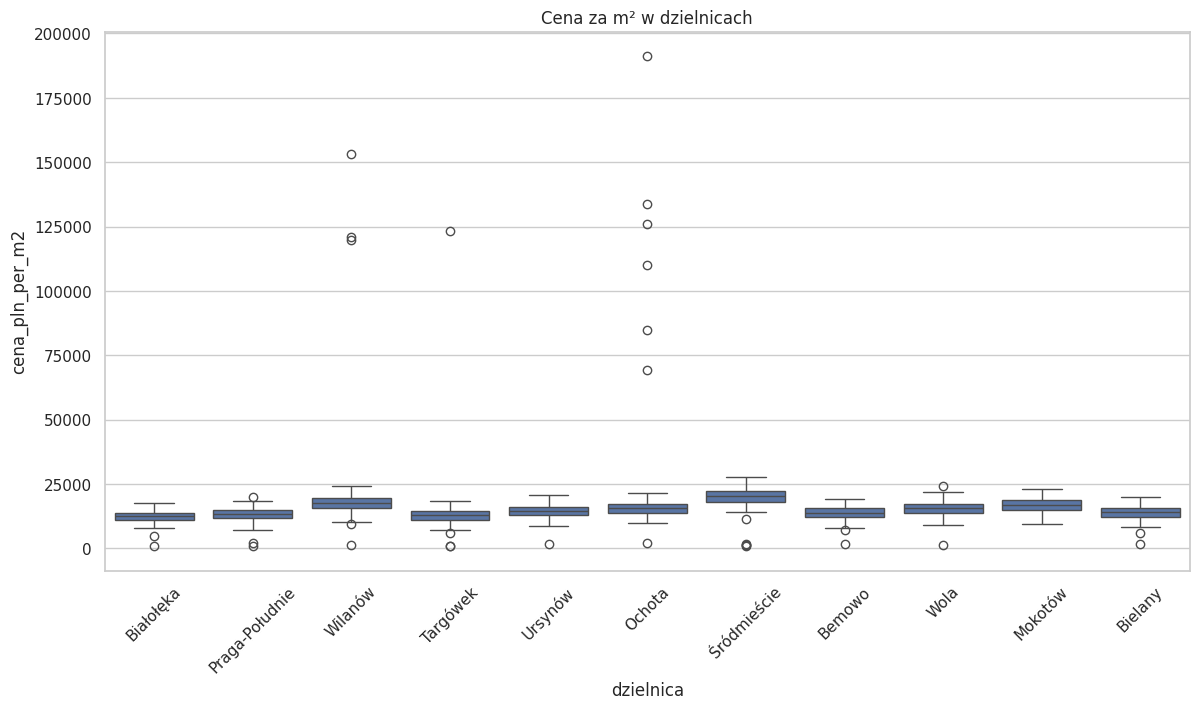


Najwyższe ceny za m² posiada zazwyczaj Śródmieście oraz Wilanów.


OUTLIERY IQR: 39
OUTLIERY Z-SCORE: 9
OUTLIERY MODIFIED Z-SCORE: 22

OUTLIERY METRAŻU:
      id_oferty       dzielnica   metraz_m2  liczba_pokoi  pietro  rok_budowy  \
1597      11598  Praga-Południe  585.187341             3       1        1972   
1845      11846        Targówek  566.921693             3       7        1990   
53        10054       Białołęka  537.356930             2       4        2010   
1681      11682        Targówek  473.491995             1      11        1961   
1050      11051  Praga-Południe  324.358377             2       8        1997   

      ma_balkon  ma_miejsce_parkingowe  odleglosc_od_centrum_km  cena_pln  \
1597       True                   True                    14.51  614202.0   
1845       True                   True                     0.71  593446.0   
53         True                   True                     6.05  595626.0   
1681       True                  False             

/tmp/ipykernel_7806/3835425973.py:418: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["cena_pln_capped"] = (
/tmp/ipykernel_7806/3835425973.py:425: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["cena_pln_log"] = np.log1p(df["cena_pln"])


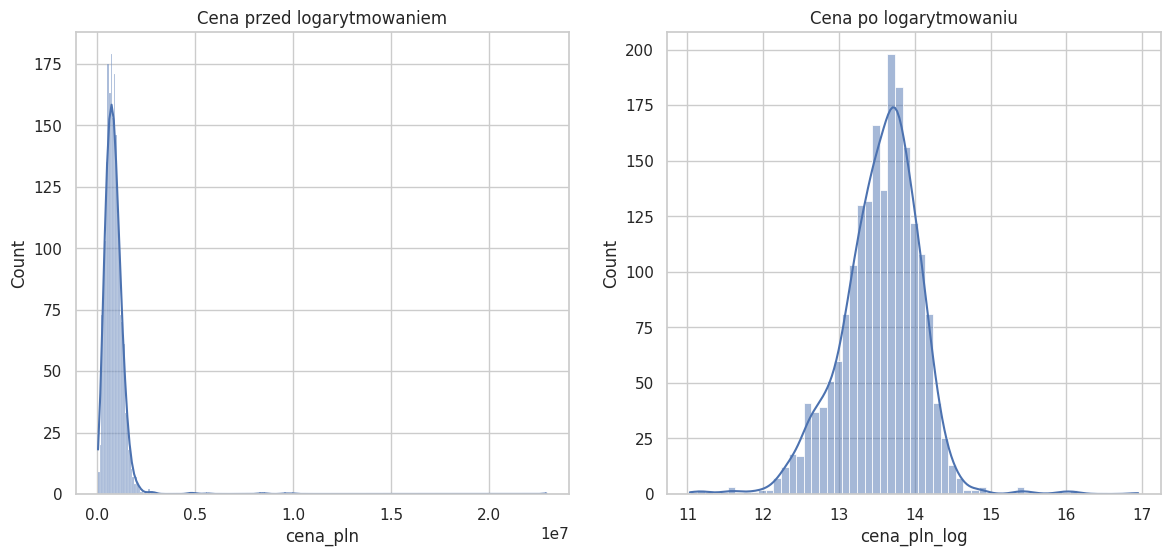


WNIOSKI:

1. Największy wpływ na cenę mieszkania ma jego metraż.

2. Śródmieście i Wilanów posiadają najwyższe ceny za m².

3. Rozkład cen mieszkań jest prawostronnie skośny,
co oznacza obecność bardzo drogich ofert.

4. W danych występują outliery i błędne wartości,
np. absurdalne ceny, ogromne metraże i błędne lata budowy.

5. Logarytmowanie ceny zmniejszyło skośność rozkładu
i poprawiło czytelność danych.



In [1]:
# ============================================
# ANALIZA RYNKU MIESZKAŃ W WARSZAWIE
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ============================================
# GENEROWANIE DANYCH
# ============================================

np.random.seed(42)

n = 2000
dzielnice = ["Mokotów", "Wola", "Śródmieście", "Praga-Południe", "Ursynów",
             "Bemowo", "Białołęka", "Targówek", "Bielany", "Ochota", "Wilanów"]

multiplikator_dzielnicy = {
    "Mokotów": 1.15,
    "Wola": 1.10,
    "Śródmieście": 1.40,
    "Praga-Południe": 0.90,
    "Ursynów": 1.00,
    "Bemowo": 0.95,
    "Białołęka": 0.85,
    "Targówek": 0.88,
    "Bielany": 0.95,
    "Ochota": 1.05,
    "Wilanów": 1.20
}

dzielnica = np.random.choice(dzielnice, n)

metraz = np.clip(np.random.normal(55, 22, n), 18, 180)

pokoje = np.clip(
    np.round(metraz / 18 + np.random.normal(0, 0.5, n)),
    1,
    6
).astype(int)

pietro = np.random.randint(0, 12, n)

rok_budowy = np.random.choice(
    list(range(1950, 2025)),
    n,
    p=np.linspace(0.5, 2, 75) / np.linspace(0.5, 2, 75).sum()
)

ma_balkon = np.random.choice([True, False], n, p=[0.75, 0.25])

ma_miejsce_parkingowe = np.random.choice(
    [True, False],
    n,
    p=[0.45, 0.55]
)

odleglosc_od_centrum = np.clip(
    np.random.gamma(2.5, 2.5, n),
    0.5,
    25
)

# Cena za m²

cena_za_m2 = (
    14000
    * np.array([multiplikator_dzielnicy[d] for d in dzielnica])
    * (1 + 0.005 * (rok_budowy - 1980))
    * (1 - 0.015 * odleglosc_od_centrum)
    * (1 + 0.05 * ma_balkon)
    * (1 + 0.08 * ma_miejsce_parkingowe)
    + np.random.normal(0, 1500, n)
)

cena = (cena_za_m2 * metraz).round(0)

df = pd.DataFrame({
    "id_oferty": range(10001, 10001 + n),
    "dzielnica": dzielnica,
    "metraz_m2": metraz.round(1),
    "liczba_pokoi": pokoje,
    "pietro": pietro,
    "rok_budowy": rok_budowy,
    "ma_balkon": ma_balkon,
    "ma_miejsce_parkingowe": ma_miejsce_parkingowe,
    "odleglosc_od_centrum_km": odleglosc_od_centrum.round(2),
    "cena_pln": cena
})

# Wstrzyknięcie outlierów

outlier_idx = np.random.choice(df.index, 30, replace=False)

df.loc[outlier_idx[:10], "cena_pln"] *= np.random.uniform(5, 12, 10)

df.loc[outlier_idx[10:20], "cena_pln"] *= np.random.uniform(0.05, 0.2, 10)

df.loc[outlier_idx[20:25], "metraz_m2"] = np.random.uniform(300, 600, 5)

df.loc[outlier_idx[25:30], "rok_budowy"] = np.random.choice(
    [1800, 1850, 2050, 2099],
    5
)

df.to_csv("mieszkania_warszawa.csv", index=False)

print("Wygenerowano plik mieszkania_warszawa.csv")

# ============================================
# WCZYTANIE DANYCH
# ============================================

df = pd.read_csv("mieszkania_warszawa.csv")

# ============================================
# CZĘŚĆ 1 — WSTĘPNA EKSPLORACJA
# ============================================

print("\nSHAPE:")
print(df.shape)

print("\nINFO:")
print(df.info())

print("\nDESCRIBE:")
print(df.describe())

print("\nBRAKI DANYCH:")
print(df.isnull().sum())

# ============================================
# KOMENTARZ
# ============================================

print("""
KOMENTARZ:

W danych można zauważyć:
- bardzo wysokie ceny mieszkań,
- bardzo duże metraże,
- nielogiczne lata budowy (np. 1800, 2099),
co sugeruje obecność outlierów i błędów.
""")

# ============================================
# CZĘŚĆ 2 — STATYSTYKI OPISOWE
# ============================================

print("\nSTATYSTYKI CENY:")

print("Średnia:", df["cena_pln"].mean())
print("Mediana:", df["cena_pln"].median())
print("Odchylenie standardowe:", df["cena_pln"].std())
print("Skewness:", df["cena_pln"].skew())
print("Kurtosis:", df["cena_pln"].kurtosis())

print("""
Skewness dodatni oznacza prawostronną skośność rozkładu.
Większość mieszkań ma niższe ceny,
ale istnieją pojedyncze bardzo drogie oferty.
""")

Q1 = df["metraz_m2"].quantile(0.25)
Q3 = df["metraz_m2"].quantile(0.75)
IQR = Q3 - Q1

print("\nMETRAŻ:")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLICZBA DZIELNIC:")
print(df["dzielnica"].nunique())

print("\nOFERTY W DZIELNICACH:")
print(df["dzielnica"].value_counts())

# ============================================
# CZĘŚĆ 3 — ANALIZA ZMIENNYCH
# ============================================

# Histogram ceny

plt.figure(figsize=(10, 6))
sns.histplot(df["cena_pln"], kde=True, bins=40)

plt.title("Histogram ceny mieszkań")
plt.xlabel("Cena")
plt.ylabel("Liczba ofert")

plt.show()

# Histogram metrażu

plt.figure(figsize=(10, 6))
sns.histplot(df["metraz_m2"], kde=True, bins=40)

plt.title("Histogram metrażu mieszkań")
plt.xlabel("Metraż")
plt.ylabel("Liczba ofert")

plt.show()

print("""
Histogramy pokazują prawostronną skośność.
Występują wartości odstające.
""")

# Boxplot ceny

plt.figure(figsize=(10, 6))
sns.boxplot(x=df["cena_pln"])

plt.title("Boxplot ceny mieszkań")

plt.show()

print("""
Na boxplocie widać dużą liczbę outlierów cenowych.
""")

# Countplot dzielnic

plt.figure(figsize=(12, 6))

kolejnosc = df["dzielnica"].value_counts().index

sns.countplot(
    data=df,
    x="dzielnica",
    order=kolejnosc
)

plt.title("Liczba ofert w dzielnicach")
plt.xticks(rotation=45)

plt.show()

# ============================================
# CZĘŚĆ 4 — ANALIZA ZALEŻNOŚCI
# ============================================

# Cena za m²

df["cena_pln_per_m2"] = (
    df["cena_pln"] / df["metraz_m2"]
)

# Korelacje

df_corr = df.copy()

df_corr["ma_balkon"] = (
    df_corr["ma_balkon"].astype(int)
)

df_corr["ma_miejsce_parkingowe"] = (
    df_corr["ma_miejsce_parkingowe"].astype(int)
)

corr = (
    df_corr.select_dtypes(include="number").corr()
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Macierz korelacji")

plt.show()

print("""
Najsilniej z ceną koreluje metraż mieszkania.
""")

# Scatter plot

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="metraz_m2",
    y="cena_pln",
    hue="dzielnica",
    alpha=0.7
)

plt.title("Metraż vs Cena")

plt.show()

# Boxplot cena za m²

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="dzielnica",
    y="cena_pln_per_m2"
)

plt.xticks(rotation=45)

plt.title("Cena za m² w dzielnicach")

plt.show()

print("""
Najwyższe ceny za m² posiada zazwyczaj Śródmieście oraz Wilanów.
""")

# ============================================
# CZĘŚĆ 5 — DETEKCJA OUTLIERÓW
# ============================================

# IQR dla ceny

Q1_cena = df["cena_pln"].quantile(0.25)
Q3_cena = df["cena_pln"].quantile(0.75)

IQR_cena = Q3_cena - Q1_cena

dolna_granica = Q1_cena - 1.5 * IQR_cena
gorna_granica = Q3_cena + 1.5 * IQR_cena

outliery_iqr = df[
    (df["cena_pln"] < dolna_granica) |
    (df["cena_pln"] > gorna_granica)
]

print("\nOUTLIERY IQR:", len(outliery_iqr))

# Z-score

z_scores = np.abs(zscore(df["cena_pln"]))

outliery_z = df[z_scores > 3]

print("OUTLIERY Z-SCORE:", len(outliery_z))

# Modified Z-score

mediana = np.median(df["cena_pln"])

MAD = np.median(
    np.abs(df["cena_pln"] - mediana)
)

modified_z = (
    0.6745 * (df["cena_pln"] - mediana) / MAD
)

outliery_mod = df[np.abs(modified_z) > 3.5]

print("OUTLIERY MODIFIED Z-SCORE:", len(outliery_mod))

# Outliery metrażu

Q1_m = df["metraz_m2"].quantile(0.25)
Q3_m = df["metraz_m2"].quantile(0.75)

IQR_m = Q3_m - Q1_m

dol_m = Q1_m - 1.5 * IQR_m
gor_m = Q3_m + 1.5 * IQR_m

outliery_metraz = df[
    (df["metraz_m2"] < dol_m) |
    (df["metraz_m2"] > gor_m)
]

print("\nOUTLIERY METRAŻU:")
print(
    outliery_metraz
    .sort_values(by="metraz_m2", ascending=False)
    .head(5)
)

# Błędne lata budowy

bledne_lata = df[
    (df["rok_budowy"] < 1900) |
    (df["rok_budowy"] > 2026)
]

print("\nBŁĘDNE LATA BUDOWY:")
print(bledne_lata)

# ============================================
# CZĘŚĆ 6 — CZYSZCZENIE
# ============================================

# Usuwanie błędnych lat

df = df[
    (df["rok_budowy"] >= 1900) &
    (df["rok_budowy"] <= 2026)
]

# Winsoryzacja ceny

p1 = df["cena_pln"].quantile(0.01)
p99 = df["cena_pln"].quantile(0.99)

df["cena_pln_capped"] = (
    df["cena_pln"]
    .clip(lower=p1, upper=p99)
)

# Logarytmowanie

df["cena_pln_log"] = np.log1p(df["cena_pln"])

print("\nSKEWNESS PRZED:")
print(df["cena_pln"].skew())

print("\nSKEWNESS PO LOG:")
print(df["cena_pln_log"].skew())

# Histogram porównawczy

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(
    df["cena_pln"],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Cena przed logarytmowaniem")

sns.histplot(
    df["cena_pln_log"],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Cena po logarytmowaniu")

plt.show()

# ============================================
# CZĘŚĆ 7 — WNIOSKI
# ============================================

print("""
WNIOSKI:

1. Największy wpływ na cenę mieszkania ma jego metraż.

2. Śródmieście i Wilanów posiadają najwyższe ceny za m².

3. Rozkład cen mieszkań jest prawostronnie skośny,
co oznacza obecność bardzo drogich ofert.

4. W danych występują outliery i błędne wartości,
np. absurdalne ceny, ogromne metraże i błędne lata budowy.

5. Logarytmowanie ceny zmniejszyło skośność rozkładu
i poprawiło czytelność danych.
""")